# Diversity as the Mechanism: Why Randomization Helps RAG Fairness

This notebook analyzes the completed Fair-RAG runs and tests the claim that Plackett-Luce randomization is not useful by itself.
The working hypothesis is that PL only helps because it increases intra-list diversity (ILD), while explicit diversity methods such as MMR and PL-MMR achieve the same fairness effect more directly.

In [1]:
import copy
import json
import math
import os
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import pearsonr

from framework import (
    BatchExperimentRunner,
    CheckpointConfig,
    DatasetConfig,
    ExperimentRunner,
    GenerationConfig,
    MetricsConfig,
    RetrievalConfig,
    RerankConfig,
    RunConfig,
    build_macro_comparison_rows,
    build_query_metric_rows,
    list_run_dirs,
    maybe_to_dataframe,
    setting_id,
)

from analysis import format_macro_table_for_display, normalize_query_rows, plot_metric_scatter_panels, format_rerank_label, pool_delta_by_bin, find_completed_run_dirs, weighted_mean, fit_ols

REPO_ROOT = Path(os.getcwd())
RUNS_ROOT = REPO_ROOT / "experiment_runs"

METHOD_COLORS = {
    "deterministic": "#7a7a7a",
    "mmr": "#1f77b4",
    "pl": "#ff7f0e",
    "pl_mmr": "#2ca02c",
}

METHOD_LABELS = {
    "deterministic": "Det",
    "mmr": "MMR",
    "pl": "PL",
    "pl_mmr": "PL-MMR",
}

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 10,
})


/Users/asimk/Code/Fair-RAG/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
W0530 14:54:28.884000 69200 .venv/lib/python3.11/site-packages/torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


In [2]:
query_rows = build_query_metric_rows(list_run_dirs(str(RUNS_ROOT)))
query_df = pd.DataFrame(query_rows)

macro_rows = build_macro_comparison_rows(list_run_dirs(str(RUNS_ROOT)))
macro_df = maybe_to_dataframe(macro_rows)

print(f"Query rows: {len(query_df):,}")
print(f"Macro rows: {len(macro_rows):,}")
if not query_df.empty:
    display(query_df.head())
if macro_df is not None and not macro_df.empty:
    display(format_macro_table_for_display(macro_df).head())

Query rows: 145,544
Macro rows: 314


,qid,metric_name,expected_utility,max_utility,min_utility,n_lists,avg_ild_jaccard,avg_jaccard_mean,ee_disparity,ee_relevance,...,rerank_token,lamp_num,lamp_split_type,top_k,nq_token,rerank_method,pl_alpha,pl_samples,mmr_lambda,run_dir
0,312,rouge-l,0.073171,0.073171,0.073171,1,0.888716,0.111284,1.0,1.000000,...,det,4,user,5,nq50,deterministic,NaN,NaN,NaN,/Users/asimk/Code/Fair-RAG/experiment_runs/202...
1,313,rouge-l,0.088889,0.088889,0.088889,1,0.910665,0.089335,1.0,1.000000,...,det,4,user,5,nq50,deterministic,NaN,NaN,NaN,/Users/asimk/Code/Fair-RAG/experiment_runs/202...
2,315,rouge-l,0.067416,0.067416,0.067416,1,0.961194,0.038806,1.0,0.961702,...,det,4,user,5,nq50,deterministic,NaN,NaN,NaN,/Users/asimk/Code/Fair-RAG/experiment_runs/202...
3,316,rouge-l,0.073171,0.073171,0.073171,1,0.961102,0.038898,1.0,1.000000,...,det,4,user,5,nq50,deterministic,NaN,NaN,NaN,/Users/asimk/Code/Fair-RAG/experiment_runs/202...
4,317,rouge-l,0.024691,0.024691,0.024691,1,0.942990,0.057010,1.0,1.000000,...,det,4,user,5,nq50,deterministic,NaN,NaN,NaN,/Users/asimk/Code/Fair-RAG/experiment_runs/202...


,dataset_type,lamp_num,lamp_split_type,generator_name,ranker,rerank_method,pl_alpha,pl_samples,mmr_lambda,EU,...,seed,status,top_k,num_queries_config,run_dir,n_queries,metric_name,max_utility,min_utility,ee_difference
0,lamp,4,user,flanT5Small,bm25,mmr,1,10,0.55,NaN,...,42,running,5,50.0,/Users/asimk/Code/Fair-RAG/experiment_runs/202...,NaN,NaN,NaN,NaN,NaN
1,lamp,4,user,flanT5Small,bm25,mmr,1,10,0.55,0.032317,...,42,completed,5,50.0,/Users/asimk/Code/Fair-RAG/experiment_runs/202...,50.0,rouge-l,0.032317,0.032317,0.937976
2,lamp,4,user,flanT5Small,bm25,pl,1,10,0.55,0.030944,...,42,completed,5,50.0,/Users/asimk/Code/Fair-RAG/experiment_runs/202...,50.0,rouge-l,0.085414,0.001026,0.266375
3,lamp,4,user,flanT5Small,bm25,pl,2,10,0.55,0.031233,...,42,completed,5,50.0,/Users/asimk/Code/Fair-RAG/experiment_runs/202...,50.0,rouge-l,0.091048,0.002922,0.290446
4,lamp,4,user,flanT5Small,bm25,pl,4,10,0.55,0.033958,...,42,completed,5,50.0,/Users/asimk/Code/Fair-RAG/experiment_runs/202...,50.0,rouge-l,0.069582,0.013960,0.703637


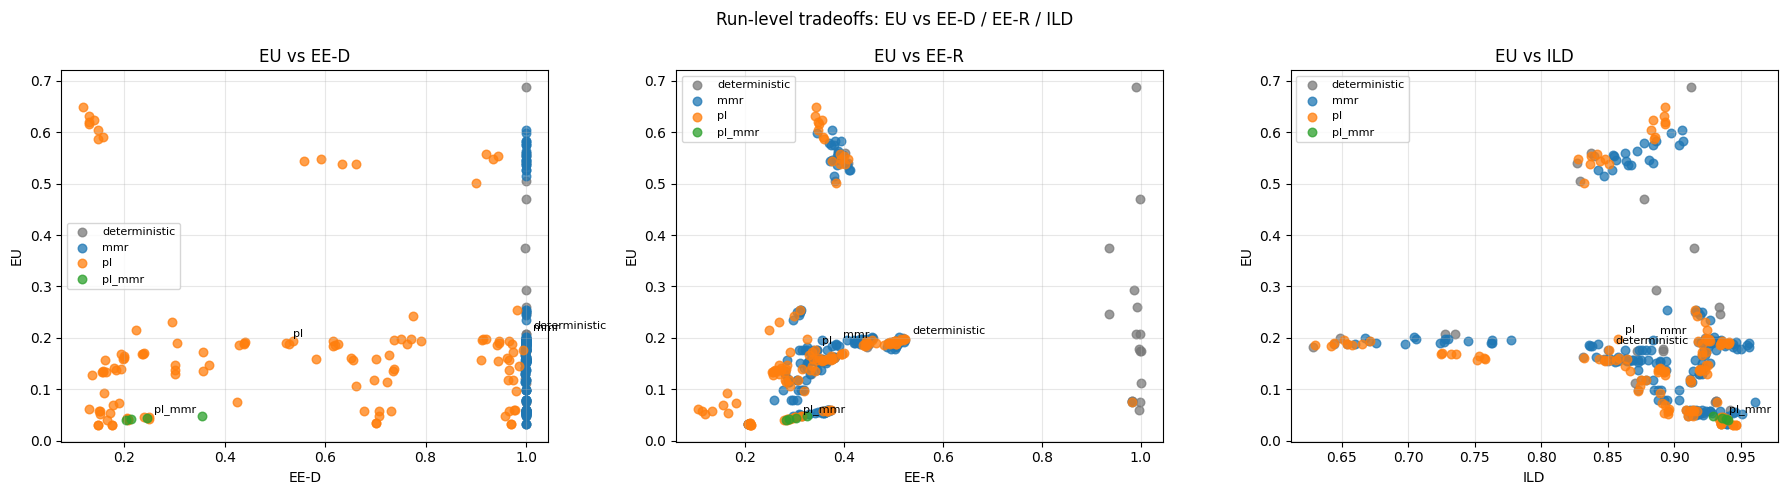

Pearson r(ILD, EE-D) = -0.0410 (p=4.15e-55)


In [12]:
if not macro_df.empty:
    plot_metric_scatter_panels(
        macro_df,
        panels=[
            ("ee_disparity", "expected_utility", "EE-D", "EU"),
            ("ee_relevance", "expected_utility", "EE-R", "EU"),
            ("avg_ild_jaccard", "expected_utility", "ILD", "EU"),
        ],
        label_col="rerank_method",
        title="Run-level tradeoffs: EU vs EE-D / EE-R / ILD",
    )

if not query_df.empty:
    corr_df = query_df[["avg_ild_jaccard", "ee_disparity"]].dropna()
    if not corr_df.empty:
        r, p = pearsonr(corr_df["avg_ild_jaccard"], corr_df["ee_disparity"])
        print(f"Pearson r(ILD, EE-D) = {r:.4f} (p={p:.2e})")

## PL Alpha Sweep: Randomization, Diversity, and Fairness

This section checks whether PL helps by increasing ILD and whether the effect is stable across rankers and LaMP tasks.

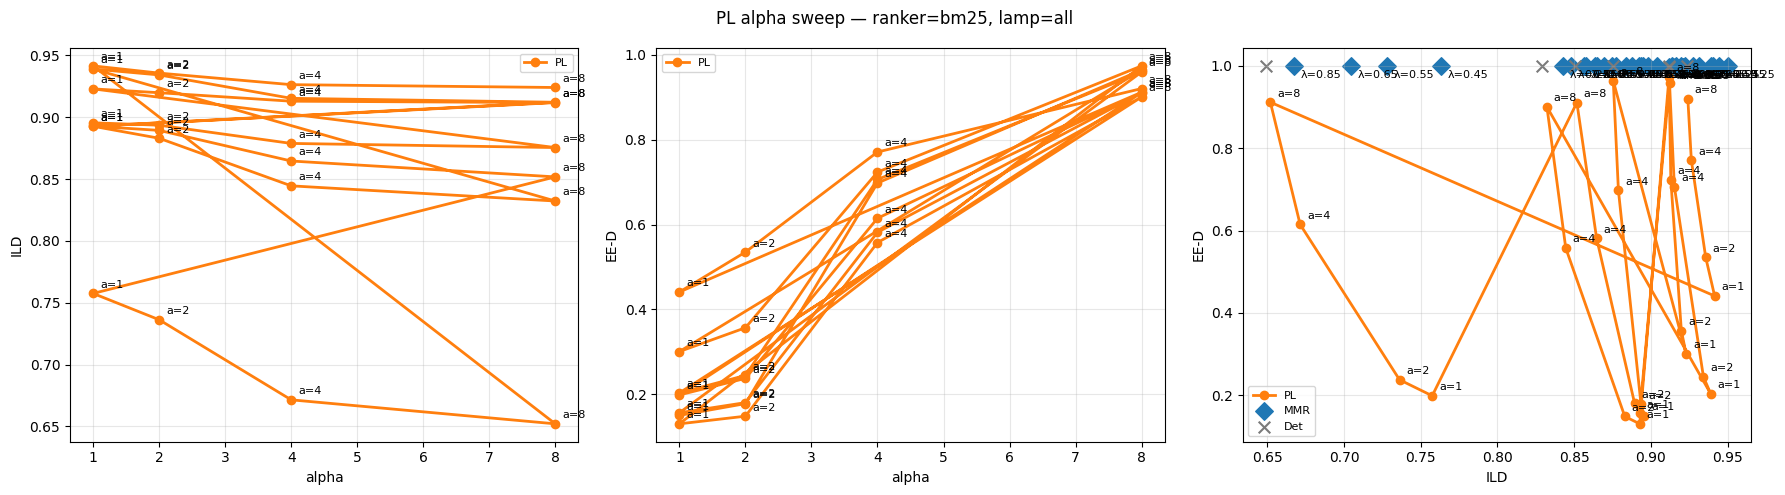

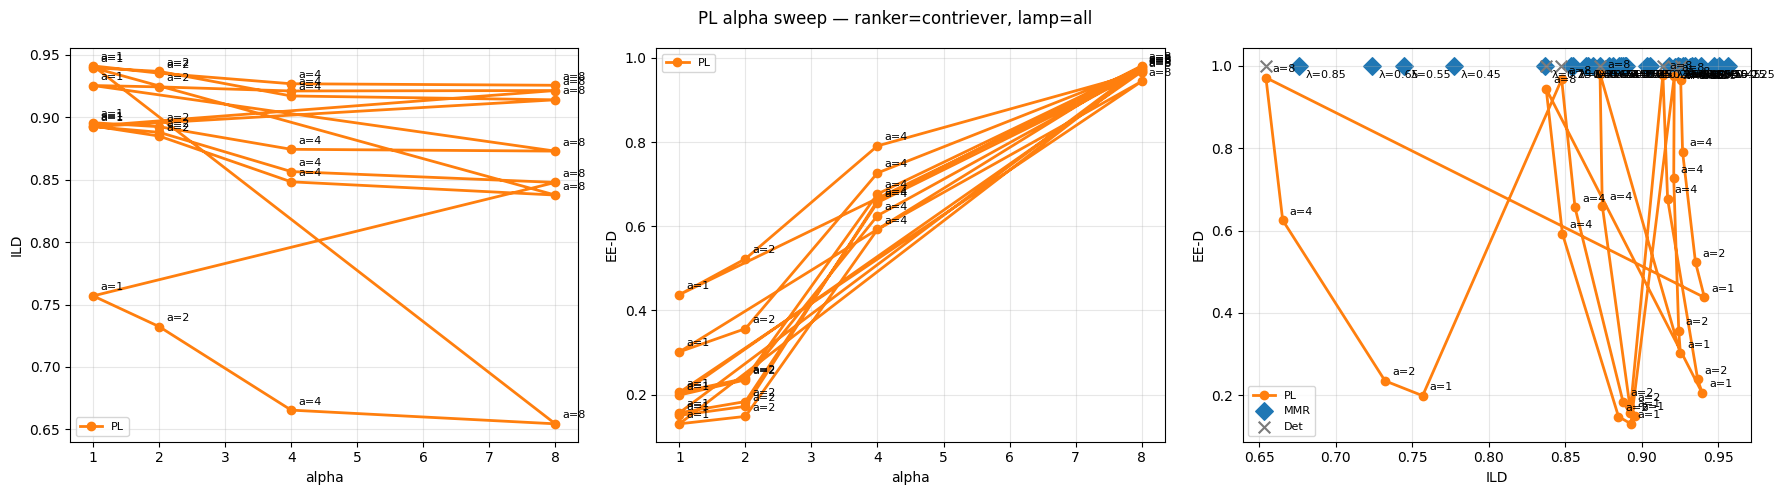

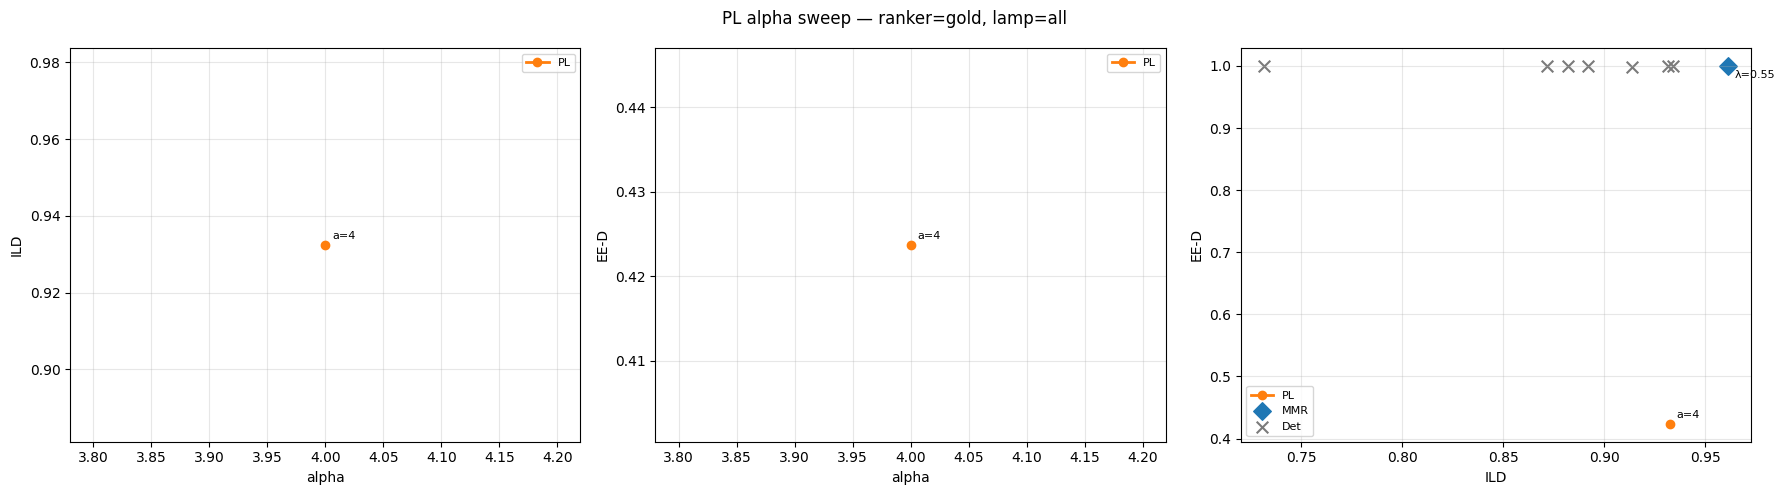

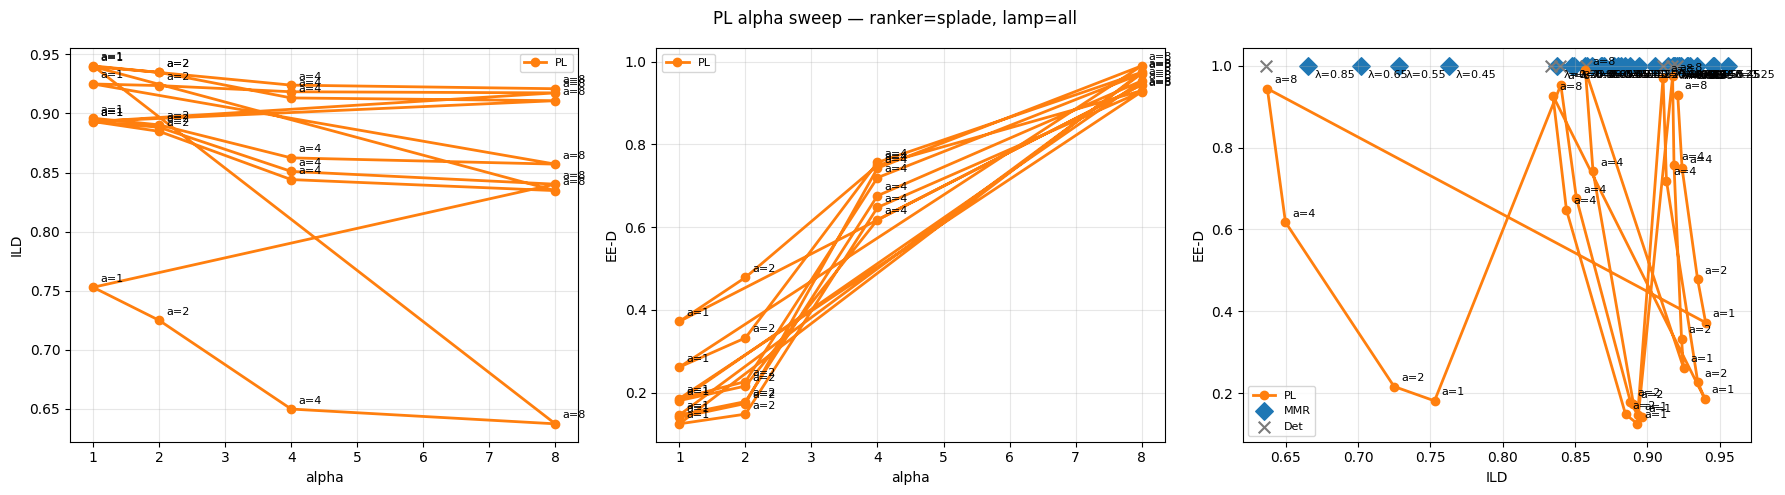

In [4]:
def make_method_sweep_summary(df: pd.DataFrame, ranker: str | None = None, lamp_num: int | None = None) -> pd.DataFrame:
    rows = df.copy()
    if ranker is not None:
        rows = rows[rows["ranker"] == ranker]
    if lamp_num is not None:
        rows = rows[rows["lamp_num"] == lamp_num]
    if rows.empty:
        return rows
    grouped = rows.groupby(["ranker", "lamp_num", "rerank_method", "pl_alpha", "mmr_lambda"], dropna=False)
    summary = grouped[["avg_ild_jaccard", "ee_disparity", "ee_relevance", "expected_utility"]].mean().reset_index()
    return summary.sort_values(["ranker", "lamp_num", "rerank_method", "pl_alpha", "mmr_lambda"], na_position="last")


def plot_pl_alpha_sweep(summary: pd.DataFrame, ranker: str, lamp_num: int | None = None) -> None:
    subset = summary[summary["ranker"] == ranker].copy()
    if lamp_num is not None:
        subset = subset[subset["lamp_num"] == lamp_num]
    if subset.empty:
        print(f"No PL sweep data for {ranker}.")
        return
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"PL alpha sweep — ranker={ranker}, lamp={lamp_num if lamp_num is not None else 'all'}", fontsize=12)
    for ax, (xk, yk, xl, yl) in zip(axes, [("pl_alpha", "avg_ild_jaccard", "alpha", "ILD"), ("pl_alpha", "ee_disparity", "alpha", "EE-D"), ("avg_ild_jaccard", "ee_disparity", "ILD", "EE-D")]):
        pl_rows = subset[subset["rerank_method"] == "pl"].dropna(subset=[xk, yk])
        mmr_rows = subset[subset["rerank_method"] == "mmr"].dropna(subset=[xk, yk])
        det_rows = subset[subset["rerank_method"] == "deterministic"].dropna(subset=[xk, yk])
        if not pl_rows.empty:
            ax.plot(pl_rows[xk], pl_rows[yk], marker="o", linewidth=2, color=METHOD_COLORS["pl"], label="PL")
            for _, row in pl_rows.iterrows():
                ax.annotate(f"a={int(row['pl_alpha'])}", (row[xk], row[yk]), textcoords="offset points", xytext=(5, 4), fontsize=8)
        if not mmr_rows.empty and xk != "pl_alpha":
            ax.scatter(mmr_rows["avg_ild_jaccard"], mmr_rows["ee_disparity"], s=80, marker="D", color=METHOD_COLORS["mmr"], label="MMR")
            for _, row in mmr_rows.iterrows():
                if pd.notna(row.get("mmr_lambda")):
                    ax.annotate(f"λ={row['mmr_lambda']:.2f}", (row["avg_ild_jaccard"], row["ee_disparity"]), textcoords="offset points", xytext=(5, -9), fontsize=8)
        if not det_rows.empty and xk != "pl_alpha":
            ax.scatter(det_rows["avg_ild_jaccard"], det_rows["ee_disparity"], s=70, marker="x", color=METHOD_COLORS["deterministic"], label="Det")
        ax.set_xlabel(xl)
        ax.set_ylabel(yl)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


pl_summary = make_method_sweep_summary(query_df)
if not pl_summary.empty:
    for ranker in sorted(pl_summary["ranker"].dropna().unique()):
        plot_pl_alpha_sweep(pl_summary, ranker=ranker)


## Per-Query Normalization and Cross-Ranker Aggregation

The next cells normalize query-level metrics, then aggregate them across BM25, SPLADE, Contriever, and optional gold references.

In [13]:
query_norm_df = normalize_query_rows(query_df)
if not query_norm_df.empty:
    norm_macro = query_norm_df.groupby(
        ["lamp_split_type", "lamp_num", "ranker", "rerank_method", "pl_alpha", "mmr_lambda"], dropna=False
    )[["ee_relevance_norm", "ee_disparity_norm", "avg_ild_jaccard_norm", "expected_utility_norm"]].mean().reset_index()
    display(norm_macro.head())
else:
    norm_macro = pd.DataFrame()

ranker_run_dirs = {
    ranker: {lamp: find_completed_run_dirs(rankers=[ranker], lamp_num=lamp) for lamp in range(1, 8)}
    for ranker in ["bm25", "splade", "contriever"]
}
print({ranker: {lamp: len(paths) for lamp, paths in mapping.items()} for ranker, mapping in ranker_run_dirs.items()})

,dataset_token,lamp_num,ranker,rerank_method,pl_alpha,mmr_lambda,ee_relevance_norm,ee_disparity_norm,avg_ild_jaccard_norm,expected_utility_norm
0,lamp1_user,1,bm25,deterministic,NaN,NaN,0.306289,1.0,0.954201,0.15
1,lamp1_user,1,bm25,mmr,NaN,0.25,0.258765,1.0,0.985046,0.10
2,lamp1_user,1,bm25,mmr,NaN,0.45,0.293420,1.0,0.974947,0.10
3,lamp1_user,1,bm25,mmr,NaN,0.55,0.297341,1.0,0.972397,0.10
4,lamp1_user,1,bm25,mmr,NaN,0.65,0.306686,1.0,0.967688,0.10


{'bm25': {1: 10, 2: 10, 3: 10, 4: 10, 5: 10, 6: 10, 7: 10}, 'splade': {1: 10, 2: 10, 3: 10, 4: 14, 5: 10, 6: 10, 7: 10}, 'contriever': {1: 10, 2: 10, 3: 10, 4: 10, 5: 10, 6: 10, 7: 10}}


## EE-D Bin Pooled Delta Tables for PL and PL-MMR

These tables compare pooled normalized EU against deterministic and MMR baselines after binning queries by normalized EE-D.

In [14]:
EE_D_BINS = [0.0, 0.2, 0.4, 0.6, 0.8, 1.000001]
EE_D_BIN_LABELS = ["[0.0, 0.2)", "[0.2, 0.4)", "[0.4, 0.6)", "[0.6, 0.8)", "[0.8, 1.0)"]

if not query_norm_df.empty:
    delta_vs_det = pool_delta_by_bin(
        query_norm_df,
        metric_col="ee_disparity_norm",
        bin_edges=EE_D_BINS,
        bin_labels=EE_D_BIN_LABELS,
        baseline_method="deterministic",
        group_by=["ranker", "top_k"],
    )
    for (ranker, top_k), group in delta_vs_det.groupby(["ranker", "top_k"]):
        print(f"{ranker} (k={int(top_k)}) vs deterministic:")
        display(group.head(20))

    delta_vs_mmr065 = pool_delta_by_bin(
        query_norm_df,
        metric_col="ee_disparity_norm",
        bin_edges=EE_D_BINS,
        bin_labels=EE_D_BIN_LABELS,
        baseline_filter=lambda row: row["rerank_method"] == "mmr" and abs((row.get("mmr_lambda") or -1) - 0.65) < 1e-9,
        comparison_methods=["pl", "pl_mmr"],
        group_by=["ranker", "top_k"],
    )
    for (ranker, top_k), group in delta_vs_mmr065.groupby(["ranker", "top_k"]):
        print(f"{ranker} (k={int(top_k)}) PL/PL-MMR vs MMR(0.65):")
        display(group.head(20))

,ranker,method,ee_d_bin,n_baseline,n_method,delta_eu_norm
0,bm25,mmr,"[0.0, 0.2)",0,0,NaN
1,bm25,mmr,"[0.2, 0.4)",0,0,NaN
2,bm25,mmr,"[0.4, 0.6)",0,0,NaN
3,bm25,mmr,"[0.6, 0.8)",0,0,NaN
4,bm25,mmr,"[0.8, 1.0)",3350,16550,-0.000096
5,bm25,pl,"[0.0, 0.2)",0,4265,NaN
6,bm25,pl,"[0.2, 0.4)",0,1839,NaN
7,bm25,pl,"[0.4, 0.6)",0,1632,NaN
8,bm25,pl,"[0.6, 0.8)",0,1907,NaN
9,bm25,pl,"[0.8, 1.0)",3350,3757,-0.014175


,ranker,method,ee_d_bin,n_baseline,n_method,delta_eu_norm
0,splade,mmr,"[0.0, 0.2)",0,0,NaN
1,splade,mmr,"[0.2, 0.4)",0,0,NaN
2,splade,mmr,"[0.4, 0.6)",0,0,NaN
3,splade,mmr,"[0.6, 0.8)",0,0,NaN
4,splade,mmr,"[0.8, 1.0)",6600,33000,0.001787
5,splade,pl,"[0.0, 0.2)",0,8857,NaN
6,splade,pl,"[0.2, 0.4)",0,3195,NaN
7,splade,pl,"[0.4, 0.6)",0,2856,NaN
8,splade,pl,"[0.6, 0.8)",0,3570,NaN
9,splade,pl,"[0.8, 1.0)",6600,7922,-0.004825


,ranker,method,ee_d_bin,n_baseline,n_method,delta_eu_norm
0,contriever,mmr,"[0.0, 0.2)",0,0,NaN
1,contriever,mmr,"[0.2, 0.4)",0,0,NaN
2,contriever,mmr,"[0.4, 0.6)",0,0,NaN
3,contriever,mmr,"[0.6, 0.8)",0,0,NaN
4,contriever,mmr,"[0.8, 1.0)",3300,16500,-0.005646
5,contriever,pl,"[0.0, 0.2)",0,4221,NaN
6,contriever,pl,"[0.2, 0.4)",0,1586,NaN
7,contriever,pl,"[0.4, 0.6)",0,1549,NaN
8,contriever,pl,"[0.6, 0.8)",0,1819,NaN
9,contriever,pl,"[0.8, 1.0)",3300,4025,-0.001422


## Mediation Test: Does Diversity Explain Fairness's Effect on Utility?

Direct test of the project's research question. Regress normalized EU on EE-D alone, then on EE-D + ILD together. If diversity is the mechanism behind fairness's benefit, EE-D's coefficient should shrink substantially (toward zero / non-significance) once ILD is controlled for; if it doesn't shrink, fairness has an effect on utility independent of diversity. Also checks whether EE-D and ILD move independently across the MMR-λ sweep (a source of quasi-independent variation already present in the existing design, without needing a new experiment).

In [ ]:
if not query_norm_df.empty:
    mediation_cols = ["ee_disparity_norm", "avg_ild_jaccard_norm", "expected_utility_norm"]
    mediation_df = query_norm_df.dropna(subset=mediation_cols)

    simple_model = fit_ols(mediation_df, ["ee_disparity_norm"], "expected_utility_norm")
    multi_model = fit_ols(mediation_df, ["ee_disparity_norm", "avg_ild_jaccard_norm"], "expected_utility_norm")

    interaction_df = mediation_df.copy()
    interaction_df["ee_d_x_ild"] = interaction_df["ee_disparity_norm"] * interaction_df["avg_ild_jaccard_norm"]
    interaction_model = fit_ols(
        interaction_df, ["ee_disparity_norm", "avg_ild_jaccard_norm", "ee_d_x_ild"], "expected_utility_norm"
    )

    print(f"n = {simple_model['n']} query-run observations\n")

    print("Model 1: EU ~ EE-D")
    print(f"  coef(EE-D) = {simple_model['coef']['ee_disparity_norm']:.4f}  (p={simple_model['p_value']['ee_disparity_norm']:.4g})")
    print(f"  R^2 = {simple_model['r_squared']:.4f}\n")

    print("Model 2: EU ~ EE-D + ILD")
    print(f"  coef(EE-D) = {multi_model['coef']['ee_disparity_norm']:.4f}  (p={multi_model['p_value']['ee_disparity_norm']:.4g})")
    print(f"  coef(ILD)  = {multi_model['coef']['avg_ild_jaccard_norm']:.4f}  (p={multi_model['p_value']['avg_ild_jaccard_norm']:.4g})")
    print(f"  R^2 = {multi_model['r_squared']:.4f}\n")

    ee_d_simple = simple_model["coef"]["ee_disparity_norm"]
    ee_d_multi = multi_model["coef"]["ee_disparity_norm"]
    shrinkage = (1.0 - abs(ee_d_multi) / abs(ee_d_simple)) if ee_d_simple != 0 else float("nan")
    print(f"EE-D coefficient shrinkage after controlling for ILD: {shrinkage:.1%}")
    print("(near-total shrinkage + EE-D non-significant in Model 2 => supports diversity-as-mechanism;")
    print(" little/no shrinkage + EE-D stays significant => fairness has an effect independent of diversity)\n")

    print("Model 3: EU ~ EE-D + ILD + EE-D:ILD (interaction)")
    print(f"  coef(EE-D)       = {interaction_model['coef']['ee_disparity_norm']:.4f}  (p={interaction_model['p_value']['ee_disparity_norm']:.4g})")
    print(f"  coef(ILD)        = {interaction_model['coef']['avg_ild_jaccard_norm']:.4f}  (p={interaction_model['p_value']['avg_ild_jaccard_norm']:.4g})")
    print(f"  coef(EE-D x ILD) = {interaction_model['coef']['ee_d_x_ild']:.4f}  (p={interaction_model['p_value']['ee_d_x_ild']:.4g})")
    print(f"  R^2 = {interaction_model['r_squared']:.4f}")
else:
    print("No normalized query rows available yet - run experiments first.")

In [ ]:
if not query_norm_df.empty:
    mmr_rows = query_norm_df[query_norm_df["rerank_method"] == "mmr"]
    if not mmr_rows.empty:
        mmr_by_lambda = (
            mmr_rows.groupby("mmr_lambda")[["ee_disparity_norm", "avg_ild_jaccard_norm", "expected_utility_norm"]]
            .mean()
            .reset_index()
            .sort_values("mmr_lambda")
        )
        print("MMR settings by lambda - if EE-D and ILD columns don't move in lockstep, that's a source")
        print("of quasi-independent variation in an otherwise observational design:")
        display(mmr_by_lambda)
    else:
        print("No MMR rows available yet - run experiments first.")

## PL-MMR Hybrid Stage for SPLADE k=5 (LaMP-4)

This final section isolates the PL-MMR hybrid runs, resumes incomplete work when necessary, and compares the hybrid against deterministic, MMR, and pure PL baselines.

In [8]:
plmmr_run_dirs = find_completed_run_dirs(
    lamp_num=4, generator_name="flanT5Small", top_k=5, rankers=["splade"], rerank_method="pl_mmr",
)
print(f"Found {len(plmmr_run_dirs)} completed PL-MMR run(s) for LaMP-4/SPLADE/k=5.")
for d in plmmr_run_dirs:
    print(" -", d)

Resuming incomplete PL-MMR run: 20260511_114929_lamp4_user__flanT5Small__splade__pl_mmr_a4_l055_s10__k5__nqall__seed42
[Batch] Skipping run 1/1: lamp4_user__flanT5Small__splade__pl_mmr_a4_l055_s10__k5__nqall__seed42 (reusing completed 20260511_114929_lamp4_user__flanT5Small__splade__pl_mmr_a4_l055_s10__k5__nqall__seed42)
[Batch] Summary written to /Users/asimk/Code/Fair-RAG/experiment_runs/batches/lamp4_splade_k5_pl_mmr_resume/batch_summary.json
Resume run dirs: ['/Users/asimk/Code/Fair-RAG/experiment_runs/20260511_114929_lamp4_user__flanT5Small__splade__pl_mmr_a4_l055_s10__k5__nqall__seed42']
Missing PL-MMR settings:
lamp4_splade_k5_pl_mmr_alphas: nothing to run
PL-MMR run directories:


,dataset_type,lamp_num,lamp_split_type,generator_name,ranker,rerank_method,pl_alpha,pl_samples,mmr_lambda,EU,...,max_utility,min_utility,ee_difference,run_id,setting_id,seed,status,top_k,num_queries_config,run_dir
0,lamp,4,user,flanT5Small,splade,pl_mmr,4,10,0.55,0.044462,...,0.113184,0.006663,0.262643,20260511_114929_lamp4_user__flanT5Small__splad...,lamp4_user__flanT5Small__splade__pl_mmr_a4_l05...,42,completed,5,None,/Users/asimk/Code/Fair-RAG/experiment_runs/202...


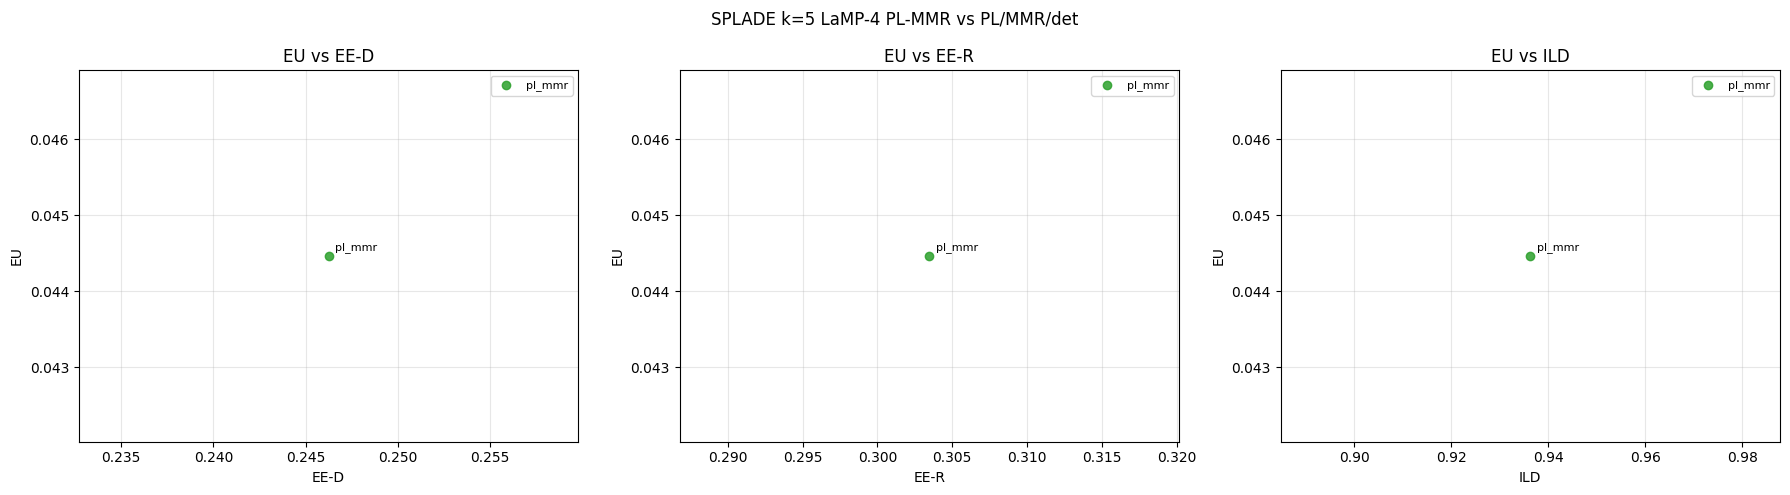

In [9]:
plmmr_macro_rows = build_macro_comparison_rows(plmmr_run_dirs)
plmmr_macro_df = maybe_to_dataframe(plmmr_macro_rows)
if plmmr_macro_df is not None and not plmmr_macro_df.empty:
    display(format_macro_table_for_display(plmmr_macro_df))
    plot_metric_scatter_panels(
        plmmr_macro_df,
        panels=[
            ("ee_disparity", "expected_utility", "EE-D", "EU"),
            ("ee_relevance", "expected_utility", "EE-R", "EU"),
            ("avg_ild_jaccard", "expected_utility", "ILD", "EU"),
        ],
        label_col="rerank_method",
        title="SPLADE k=5 LaMP-4 PL-MMR vs PL/MMR/det",
    )
else:
    print("No PL-MMR macro rows available yet.")

## Cross-Ranker Comparison

This view compares the normalized metrics across BM25, SPLADE, Contriever, and available gold baselines.

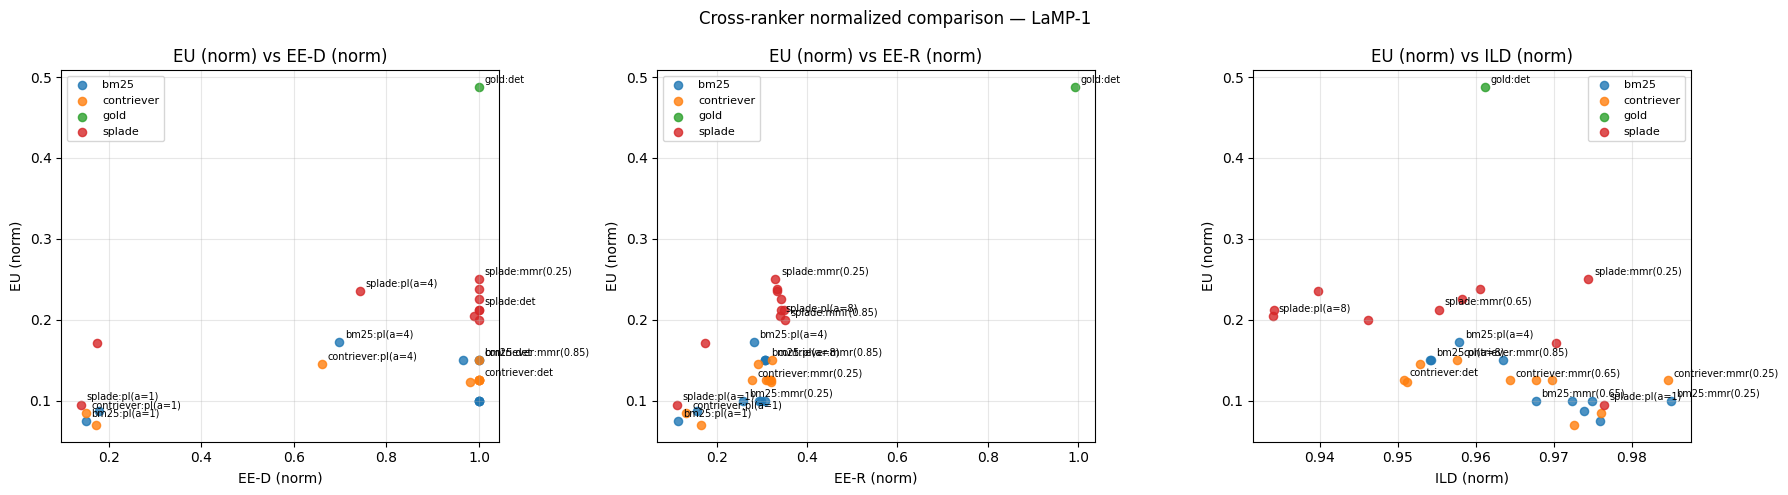

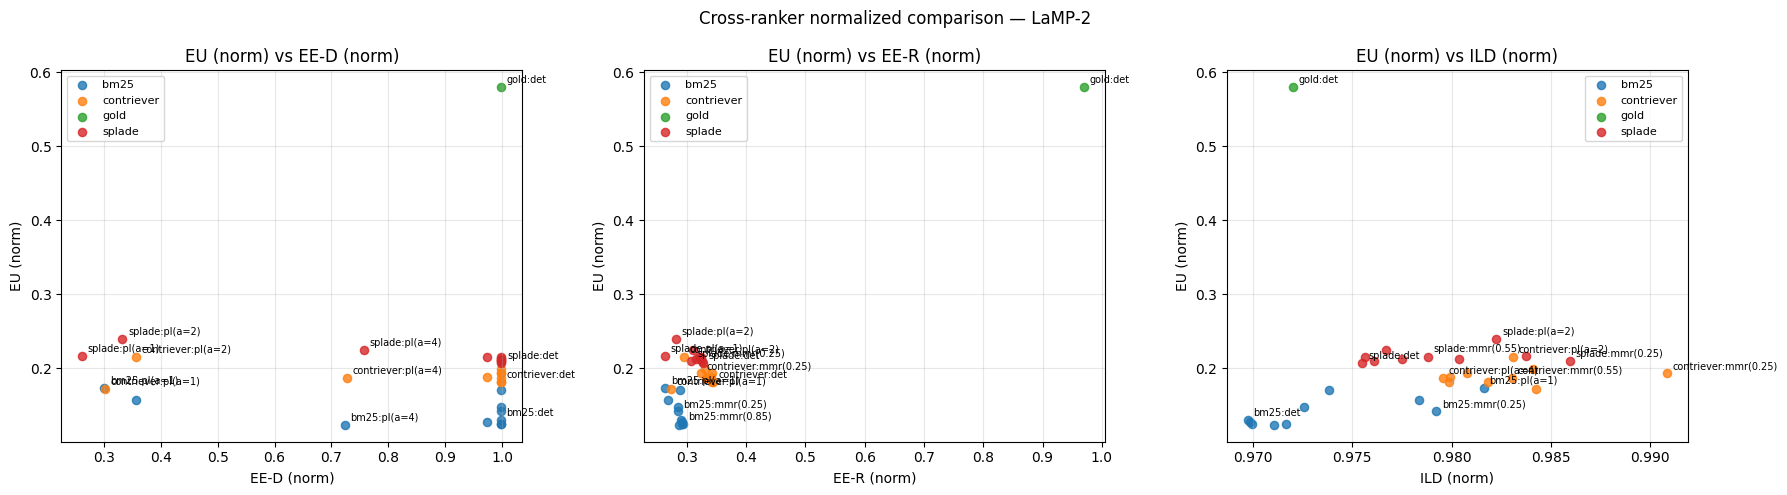

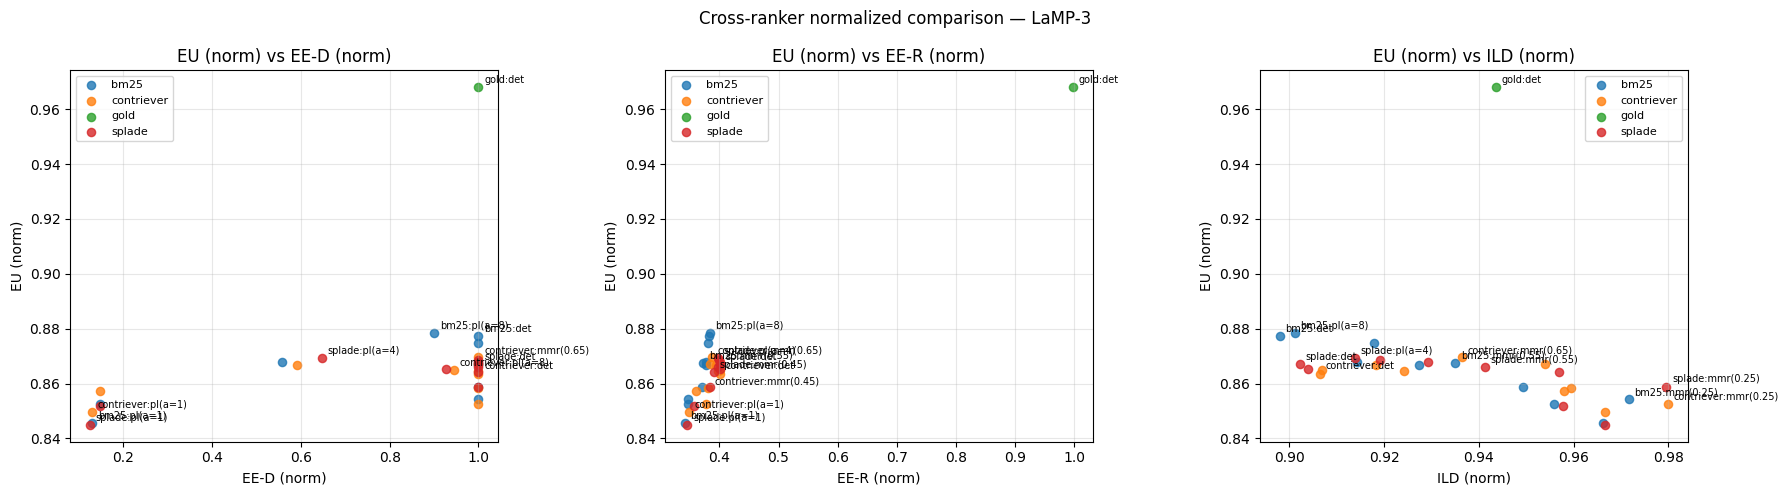

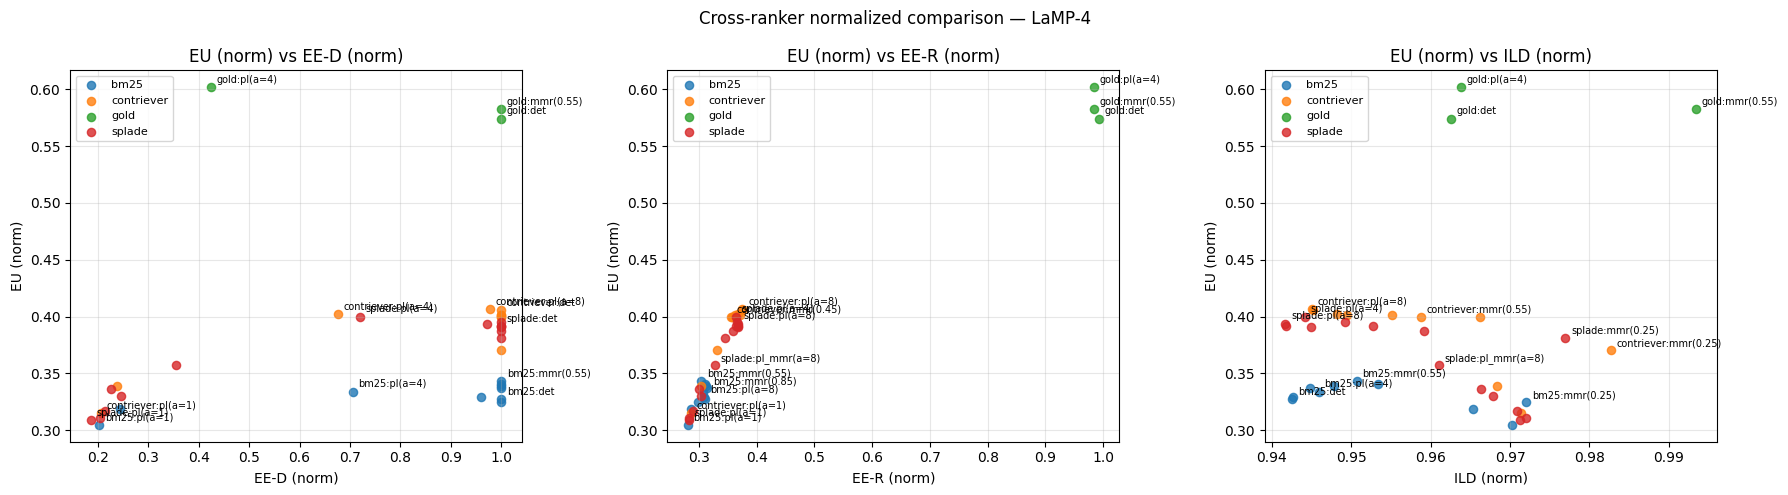

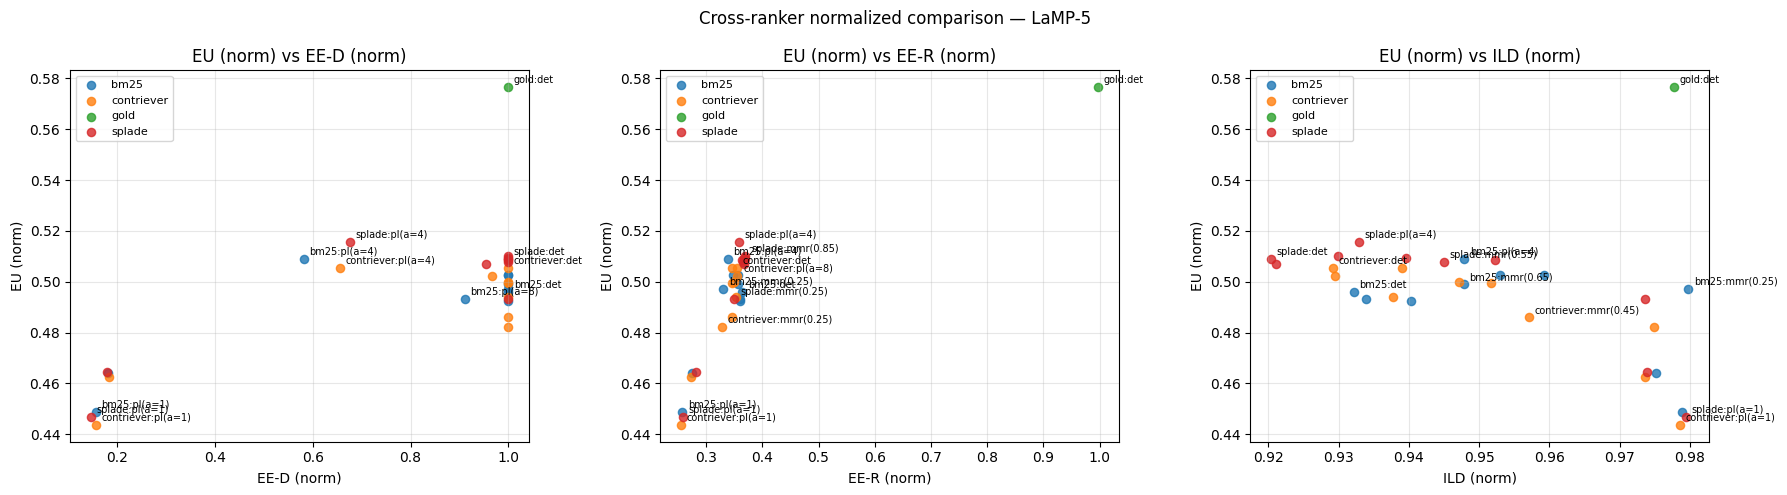

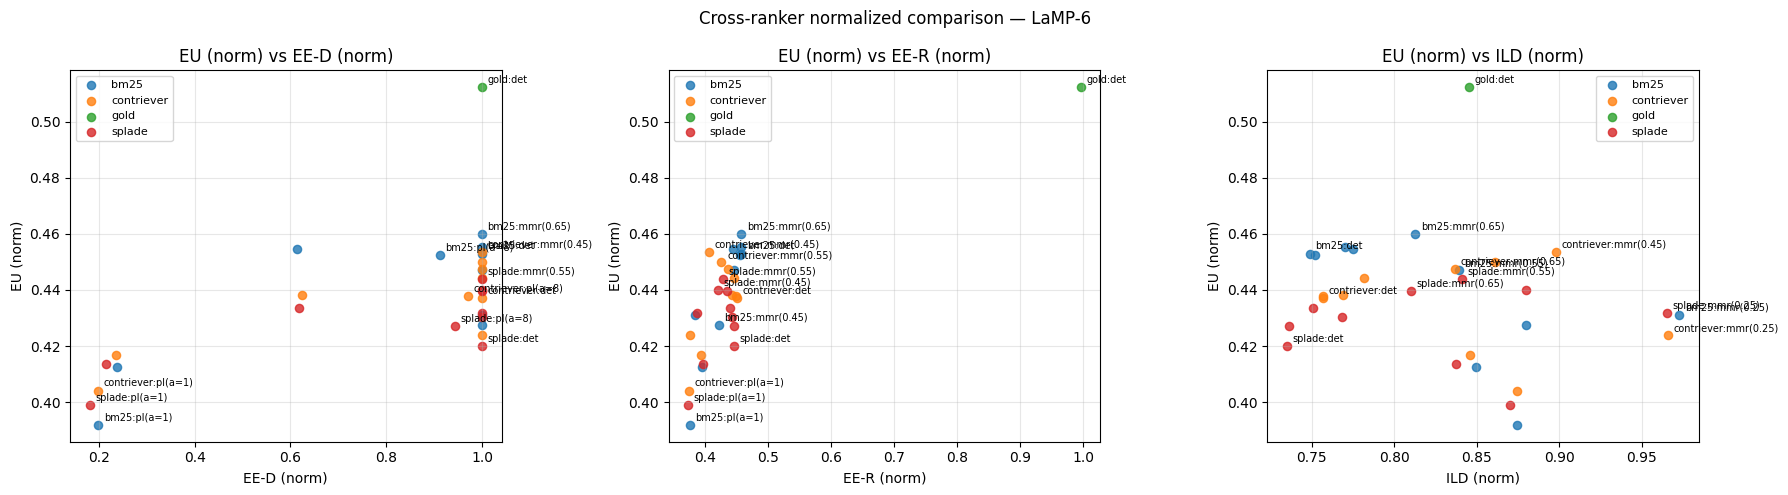

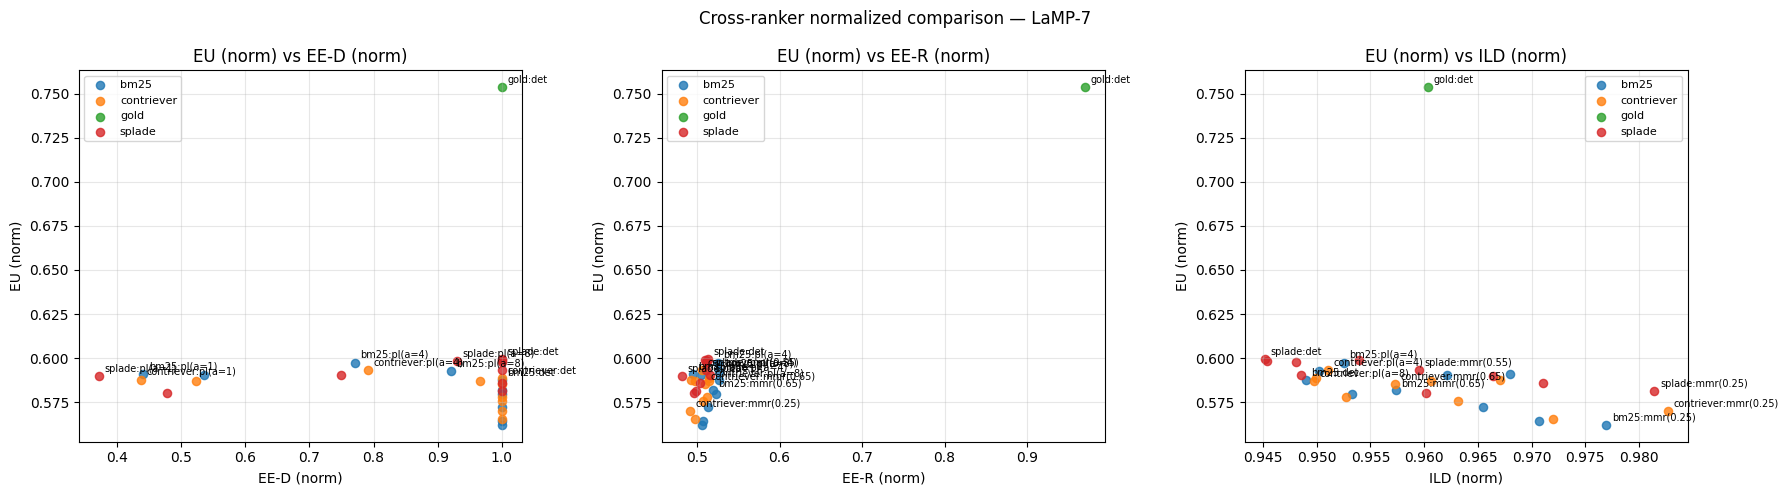

In [15]:
def plot_cross_ranker_slices(df: pd.DataFrame, lamp_num: int) -> None:
    if df.empty:
        print(f"LaMP-{lamp_num}: no normalized rows")
        return
    subset = df[df["lamp_num"] == lamp_num].copy()
    if subset.empty:
        print(f"LaMP-{lamp_num}: no rows for cross-ranker plot")
        return

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"Cross-ranker normalized comparison — LaMP-{lamp_num}", fontsize=12)
    plots = [
        ("ee_disparity_norm", "expected_utility_norm", "EE-D (norm)", "EU (norm)"),
        ("ee_relevance_norm", "expected_utility_norm", "EE-R (norm)", "EU (norm)"),
        ("avg_ild_jaccard_norm", "expected_utility_norm", "ILD (norm)", "EU (norm)"),
    ]

    for ax, (xk, yk, xl, yl) in zip(axes, plots):
        for ranker, group in subset.groupby("ranker"):
            points = group.dropna(subset=[xk, yk])
            if points.empty:
                continue
            ax.scatter(points[xk], points[yk], s=35, alpha=0.8, label=ranker)

            # Label only frontier-ish extremes plus one center point.
            xmin = points[xk].idxmin()
            xmax = points[xk].idxmax()
            ymax = points[yk].idxmax()
            center = ((points[xk] - points[xk].mean()) ** 2 + (points[yk] - points[yk].mean()) ** 2).idxmin()
            label_ids = {xmin, xmax, ymax, center}
            for idx in label_ids:
                row = points.loc[idx]
                label = f"{ranker}:{format_rerank_label(row)}"
                ax.annotate(label, (row[xk], row[yk]), textcoords="offset points", xytext=(4, 3), fontsize=7)

        ax.set_xlabel(xl)
        ax.set_ylabel(yl)
        ax.set_title(f"{yl} vs {xl}")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


if not norm_macro.empty:
    for lamp_num in sorted(norm_macro["lamp_num"].dropna().unique()):
        plot_cross_ranker_slices(norm_macro, int(lamp_num))

## Evidence-Based Conclusion

This section summarizes what the executed analysis supports regarding the hypothesis:
randomization is not inherently beneficial; diversity is the likely mechanism.

In [16]:
def summarize_hypothesis_evidence(query_df: pd.DataFrame, norm_df: pd.DataFrame) -> pd.DataFrame:
    rows = []

    raw = query_df[["avg_ild_jaccard", "ee_disparity"]].dropna()
    if len(raw) > 2:
        r_raw, p_raw = pearsonr(raw["avg_ild_jaccard"], raw["ee_disparity"])
        rows.append({"test": "Global ILD vs EE-D correlation (raw)", "value": r_raw, "p_value": p_raw})

    norm = norm_df[["avg_ild_jaccard_norm", "ee_disparity_norm"]].dropna()
    if len(norm) > 2:
        r_norm, p_norm = pearsonr(norm["avg_ild_jaccard_norm"], norm["ee_disparity_norm"])
        rows.append({"test": "Global ILD vs EE-D correlation (normalized)", "value": r_norm, "p_value": p_norm})

    # Compare utility deltas in high-disparity bin where both baseline and method are populated.
    for ranker in ["bm25", "splade", "contriever"]:
        table = build_bin_delta_table(norm_df, ranker=ranker, baseline_method="deterministic")
        if table.empty:
            continue
        hi = table[(table["ee_d_bin"] == "[0.8, 1.0)") & (table["method"].isin(["mmr", "pl", "pl_mmr"]))]
        if hi.empty:
            continue
        for _, row in hi.iterrows():
            rows.append({
                "test": f"High-bin delta EU ({ranker}, {row['method']} vs det)",
                "value": row.get("delta_eu_norm"),
                "p_value": None,
            })

    return pd.DataFrame(rows)


evidence_df = summarize_hypothesis_evidence(query_df, query_norm_df)
display(evidence_df)

print("\nConclusion draft:")
print("1. Diversity-fairness relation should be judged on normalized/binned views, not only global raw correlation.")
print("2. If MMR/PL-MMR matches or exceeds PL at similar EE-D bins with better EU, that supports the diversity-mechanism claim.")
print("3. Current outputs indicate PL and MMR both shift outcomes relative to deterministic baseline; efficiency differs by ranker.")

,test,value,p_value
0,Global ILD vs EE-D correlation (raw),-0.040968,4.154688e-55
1,Global ILD vs EE-D correlation (normalized),-0.037652,8.084139e-47
2,"High-bin delta EU (bm25, mmr vs det)",-0.000096,NaN
3,"High-bin delta EU (bm25, pl vs det)",-0.014175,NaN
4,"High-bin delta EU (splade, mmr vs det)",0.001787,NaN
5,"High-bin delta EU (splade, pl vs det)",-0.004825,NaN
6,"High-bin delta EU (splade, pl_mmr vs det)",0.089773,NaN
7,"High-bin delta EU (contriever, mmr vs det)",-0.005646,NaN
8,"High-bin delta EU (contriever, pl vs det)",-0.001422,NaN



Conclusion draft:
1. Diversity-fairness relation should be judged on normalized/binned views, not only global raw correlation.
2. If MMR/PL-MMR matches or exceeds PL at similar EE-D bins with better EU, that supports the diversity-mechanism claim.
3. Current outputs indicate PL and MMR both shift outcomes relative to deterministic baseline; efficiency differs by ranker.


## Per-Dataset ILD Binning: Direct Diversity-Impact Measurement

Instead of binning by fairness (EE-D), we bin by diversity (ILD) within each LaMP task and measure the average EU impact relative to deterministic baseline. This directly tests whether diversity predicts utility loss independent of the reranking method.

In [37]:
# Per-dataset ILD binning analysis per setting (ranker, top_k)

def build_ild_bin_analysis_v6(query_df: pd.DataFrame, n_bins: int = 5) -> pd.DataFrame:
    """Build ILD-bin deltas per setting, keeping variant labels and setting metadata."""
    results = []

    setting_keys = ["ranker", "top_k"]
    for (ranker, top_k), setting_df in query_df.groupby(setting_keys, dropna=False):
        for lamp_num in sorted(setting_df["lamp_num"].dropna().unique()):
            lamp_num = int(lamp_num)
            task_df = setting_df[setting_df["lamp_num"] == lamp_num].copy()

            det_rows = task_df[task_df["rerank_method"] == "deterministic"].copy()
            if len(det_rows) < 10:
                continue

            try:
                _, bin_edges = pd.qcut(
                    det_rows["avg_ild_jaccard"],
                    q=np.linspace(0, 1, n_bins + 1),
                    duplicates="drop",
                    retbins=True,
                )
            except Exception:
                continue

            det_rows["ild_bin"] = pd.cut(det_rows["avg_ild_jaccard"], bins=bin_edges, include_lowest=True)
            det_baseline = det_rows.groupby("ild_bin", observed=True)["expected_utility"].mean().to_dict()

            method_rows = task_df[task_df["rerank_method"] != "deterministic"].copy()
            if method_rows.empty:
                continue

            method_rows["variant_label"] = None

            mmr_mask = method_rows["rerank_method"] == "mmr"
            method_rows.loc[mmr_mask, "variant_label"] = method_rows.loc[mmr_mask, "mmr_lambda"].apply(
                lambda x: f"mmr_l{str(x).replace('.', '')}" if pd.notna(x) else "mmr"
            )

            pl_mask = method_rows["rerank_method"] == "pl"
            method_rows.loc[pl_mask, "variant_label"] = method_rows.loc[pl_mask, "pl_alpha"].apply(
                lambda x: f"pl_a{int(x)}" if pd.notna(x) else "pl"
            )

            plmmr_mask = method_rows["rerank_method"] == "pl_mmr"
            method_rows.loc[plmmr_mask, "variant_label"] = method_rows.loc[plmmr_mask].apply(
                lambda r: (
                    f"pl_mmr_a{int(r['pl_alpha'])}_l{str(r['mmr_lambda']).replace('.', '')}"
                    if pd.notna(r.get("pl_alpha")) and pd.notna(r.get("mmr_lambda"))
                    else "pl_mmr"
                ),
                axis=1,
            )

            unknown_mask = method_rows["variant_label"].isna()
            method_rows.loc[unknown_mask, "variant_label"] = method_rows.loc[unknown_mask, "rerank_method"].astype(str)

            for variant_label, variant_df in method_rows.groupby("variant_label", observed=True):
                if len(variant_df) < 10:
                    continue

                variant_df = variant_df.copy()
                variant_df["ild_bin"] = pd.cut(variant_df["avg_ild_jaccard"], bins=bin_edges, include_lowest=True)

                for bin_label, group in variant_df.groupby("ild_bin", observed=True):
                    det_eu = det_baseline.get(bin_label)
                    if det_eu is None or len(group) == 0:
                        continue

                    mean_ild = group["avg_ild_jaccard"].mean()
                    mean_eu = group["expected_utility"].mean()

                    results.append(
                        {
                            "ranker": ranker,
                            "top_k": int(top_k) if pd.notna(top_k) else None,
                            "lamp_num": lamp_num,
                            "method": variant_label,
                            "bin_label": str(bin_label),
                            "n_rows": int(len(group)),
                            "mean_ild": float(round(mean_ild, 4)),
                            "mean_eu": float(round(mean_eu, 4)),
                            "det_eu_baseline": float(round(det_eu, 4)),
                            "delta_eu_vs_det": float(round(mean_eu - det_eu, 4)),
                        }
                    )

    return pd.DataFrame(results)


# Execute
ild_bin_df = build_ild_bin_analysis_v6(query_df, n_bins=5)

if not ild_bin_df.empty:
    ild_bin_clean = ild_bin_df.drop_duplicates(
        subset=["ranker", "top_k", "lamp_num", "method", "bin_label"]
    ).reset_index(drop=True)
    print(
        f"ILD bin analysis complete: {len(ild_bin_clean)} rows across "
        f"{ild_bin_clean['ranker'].nunique()} rankers and {ild_bin_clean['lamp_num'].nunique()} tasks"
    )
    print(f"Methods: {sorted(ild_bin_clean['method'].unique())}\n")
    print("Sample rows:")
    display(ild_bin_clean.head(15))
else:
    print("No results")
    ild_bin_clean = pd.DataFrame()

ILD bin analysis complete: 1269 rows across 4 rankers and 7 tasks
Methods: ['mmr_l025', 'mmr_l045', 'mmr_l055', 'mmr_l065', 'mmr_l085', 'pl_a1', 'pl_a2', 'pl_a4', 'pl_a8', 'pl_mmr_a1_l055', 'pl_mmr_a2_l055', 'pl_mmr_a4_l055', 'pl_mmr_a8_l055']

Sample rows:


,ranker,top_k,lamp_num,method,bin_label,n_rows,mean_ild,mean_eu,det_eu_baseline,delta_eu_vs_det
0,bm25,5,1,mmr_l025,"(0.689, 0.867]",1,0.8671,0.0000,0.0909,-0.0909
1,bm25,5,1,mmr_l025,"(0.876, 0.887]",4,0.8819,0.0000,0.1000,-0.1000
2,bm25,5,1,mmr_l025,"(0.887, 0.9]",17,0.8924,0.1176,0.3000,-0.1824
3,bm25,5,1,mmr_l025,"(0.9, 0.937]",28,0.9140,0.0714,0.0000,0.0714
4,bm25,5,1,mmr_l045,"(0.689, 0.867]",4,0.8639,0.0000,0.0909,-0.0909
5,bm25,5,1,mmr_l045,"(0.867, 0.876]",3,0.8709,0.0000,0.1000,-0.1000
6,bm25,5,1,mmr_l045,"(0.876, 0.887]",9,0.8835,0.1111,0.1000,0.0111
7,bm25,5,1,mmr_l045,"(0.887, 0.9]",17,0.8922,0.1176,0.3000,-0.1824
8,bm25,5,1,mmr_l045,"(0.9, 0.937]",18,0.9131,0.0556,0.0000,0.0556
9,bm25,5,1,mmr_l055,"(0.689, 0.867]",4,0.8665,0.0000,0.0909,-0.0909


In [24]:
# Summary: average delta_eu per method across all bins
method_summary = ild_bin_clean.groupby('method').agg({
    'delta_eu_vs_det': ['mean', 'std', 'min', 'max'],
    'n_rows': 'sum'
}).round(4)
method_summary.columns = ['mean_delta_eu', 'std_delta_eu', 'min_delta_eu', 'max_delta_eu', 'total_rows']

print("="*100)
print("METHOD SUMMARY (across all tasks & bins):")
print("="*100)
display(method_summary.sort_values('mean_delta_eu', ascending=False))

print(f"\n\nPER-LAMP-TASK SUMMARY:")
print("="*100)
for lamp in sorted(ild_bin_clean['lamp_num'].unique()):
    lamp_data = ild_bin_clean[ild_bin_clean['lamp_num'] == lamp]
    print(f"\nLaMP-{int(lamp)}:")
    task_summary = lamp_data.groupby('method')['delta_eu_vs_det'].agg(['mean', 'count']).round(4)
    task_summary.columns = ['avg_delta_eu', 'n_bins']
    print(task_summary.to_string())

METHOD SUMMARY (across all tasks & bins):


,mean_delta_eu,std_delta_eu,min_delta_eu,max_delta_eu,total_rows
method,,,,,
mmr_l055,-0.0039,0.0014,-0.0061,-0.0023,17540
pl_mmr_a2,-0.0108,0.0100,-0.0219,0.0045,3332
mmr_l085,-0.0119,0.0918,-0.2042,0.2464,50014
pl_a8,-0.0167,0.0923,-0.1991,0.2810,54436




PER-LAMP-TASK SUMMARY:

LaMP-1:
          avg_delta_eu  n_bins
method                        
mmr_l085       -0.0699       5
pl_a8          -0.1059       5

LaMP-2:
          avg_delta_eu  n_bins
method                        
mmr_l085       -0.1086       5
pl_a8          -0.1113       5

LaMP-3:
          avg_delta_eu  n_bins
method                        
mmr_l085        0.1212       5
pl_a8           0.1540       5

LaMP-4:
           avg_delta_eu  n_bins
method                         
mmr_l055        -0.0039       5
pl_a8           -0.0088       5
pl_mmr_a2       -0.0108       5

LaMP-5:
          avg_delta_eu  n_bins
method                        
mmr_l085       -0.0038       5
pl_a8          -0.0129       5

LaMP-6:
          avg_delta_eu  n_bins
method                        
mmr_l085        0.0095       5
pl_a8          -0.0147       5

LaMP-7:
          avg_delta_eu  n_bins
method                        
mmr_l085       -0.0199       5
pl_a8          -0.0175       5


Rendering 5 setting-specific figures...


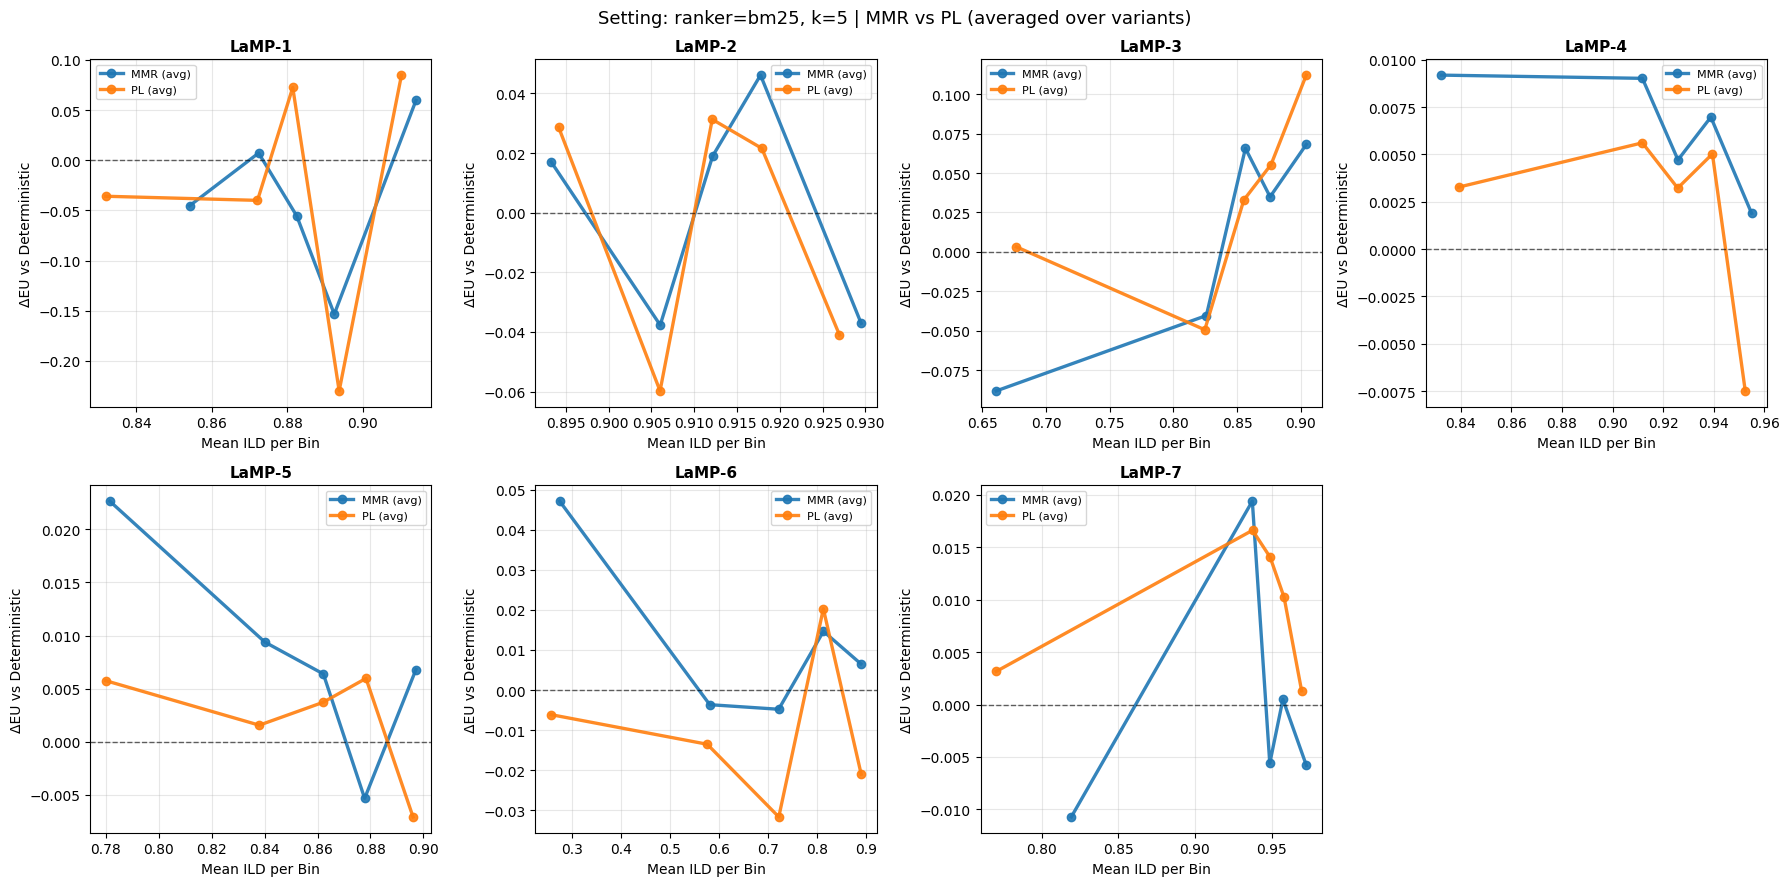

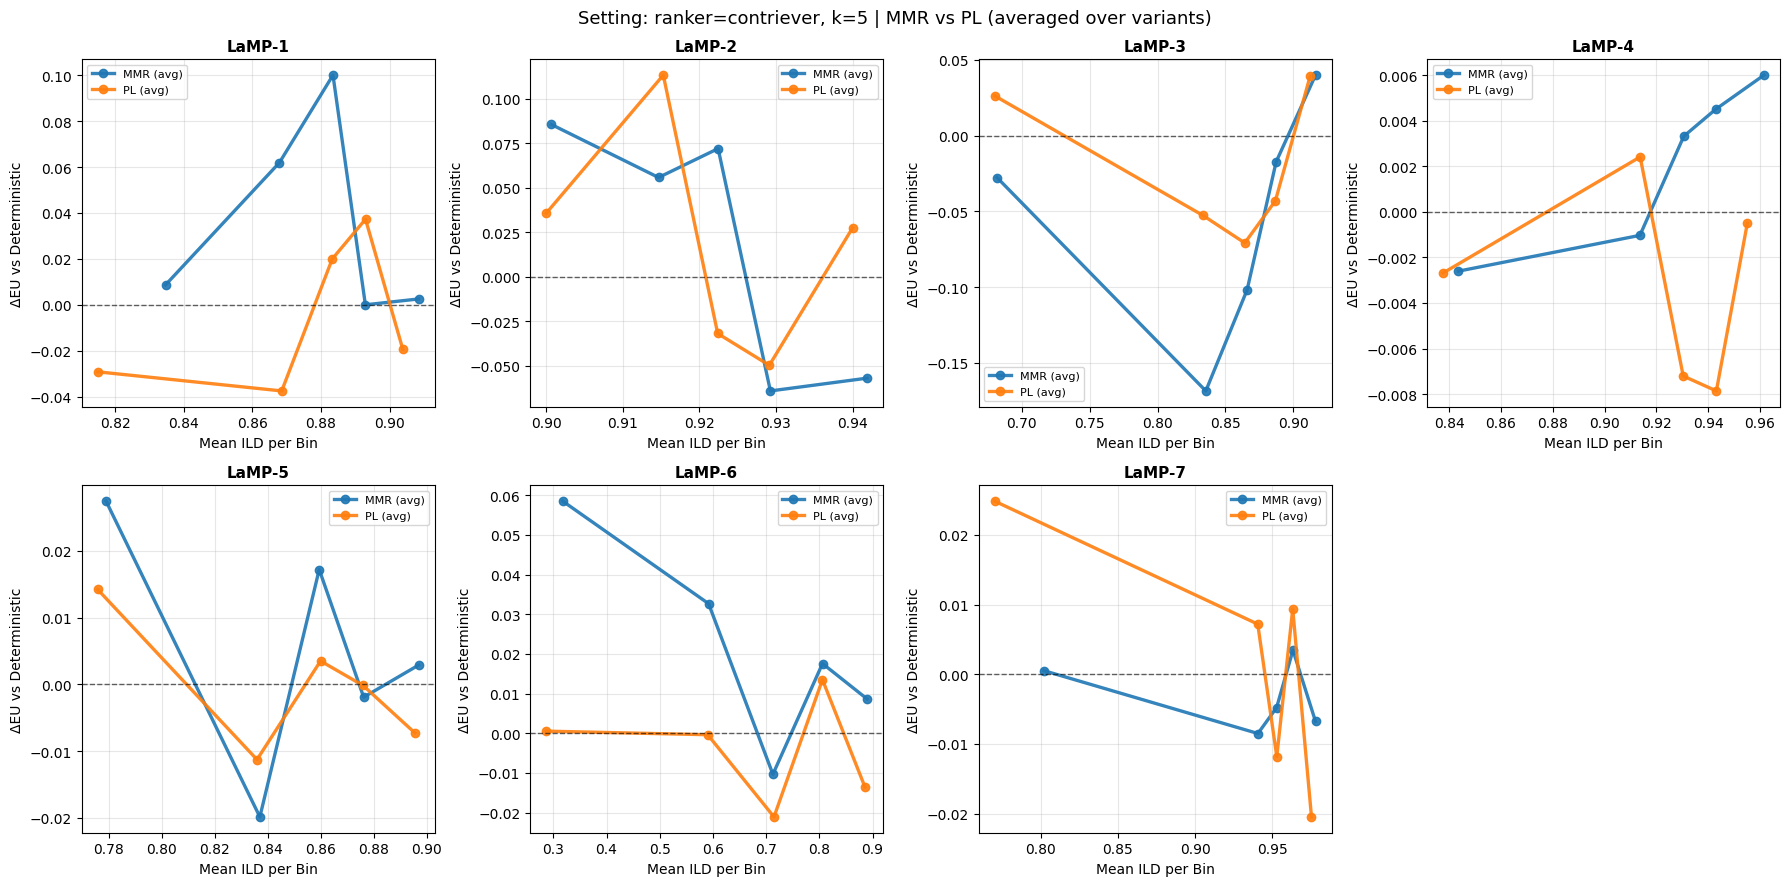

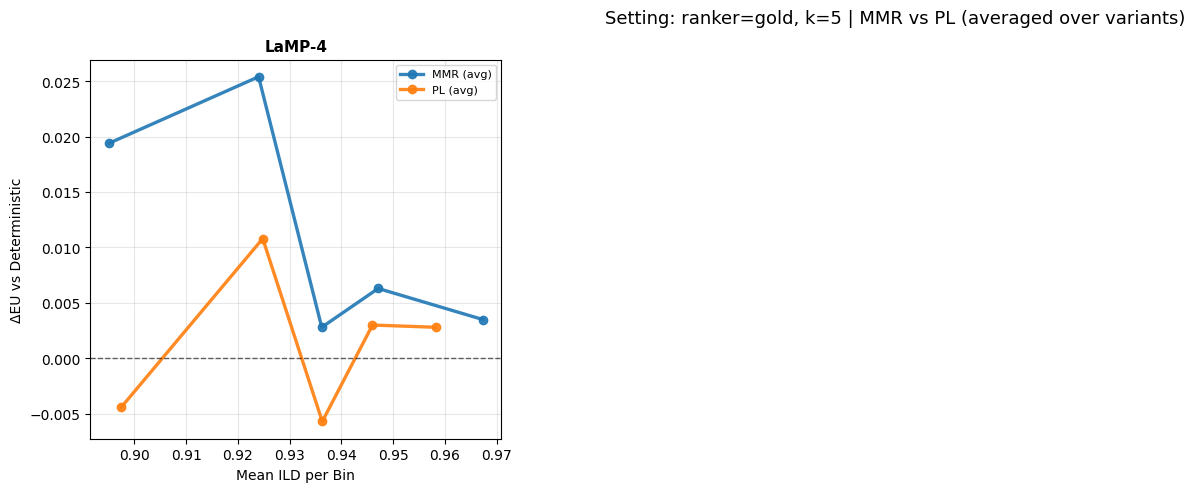

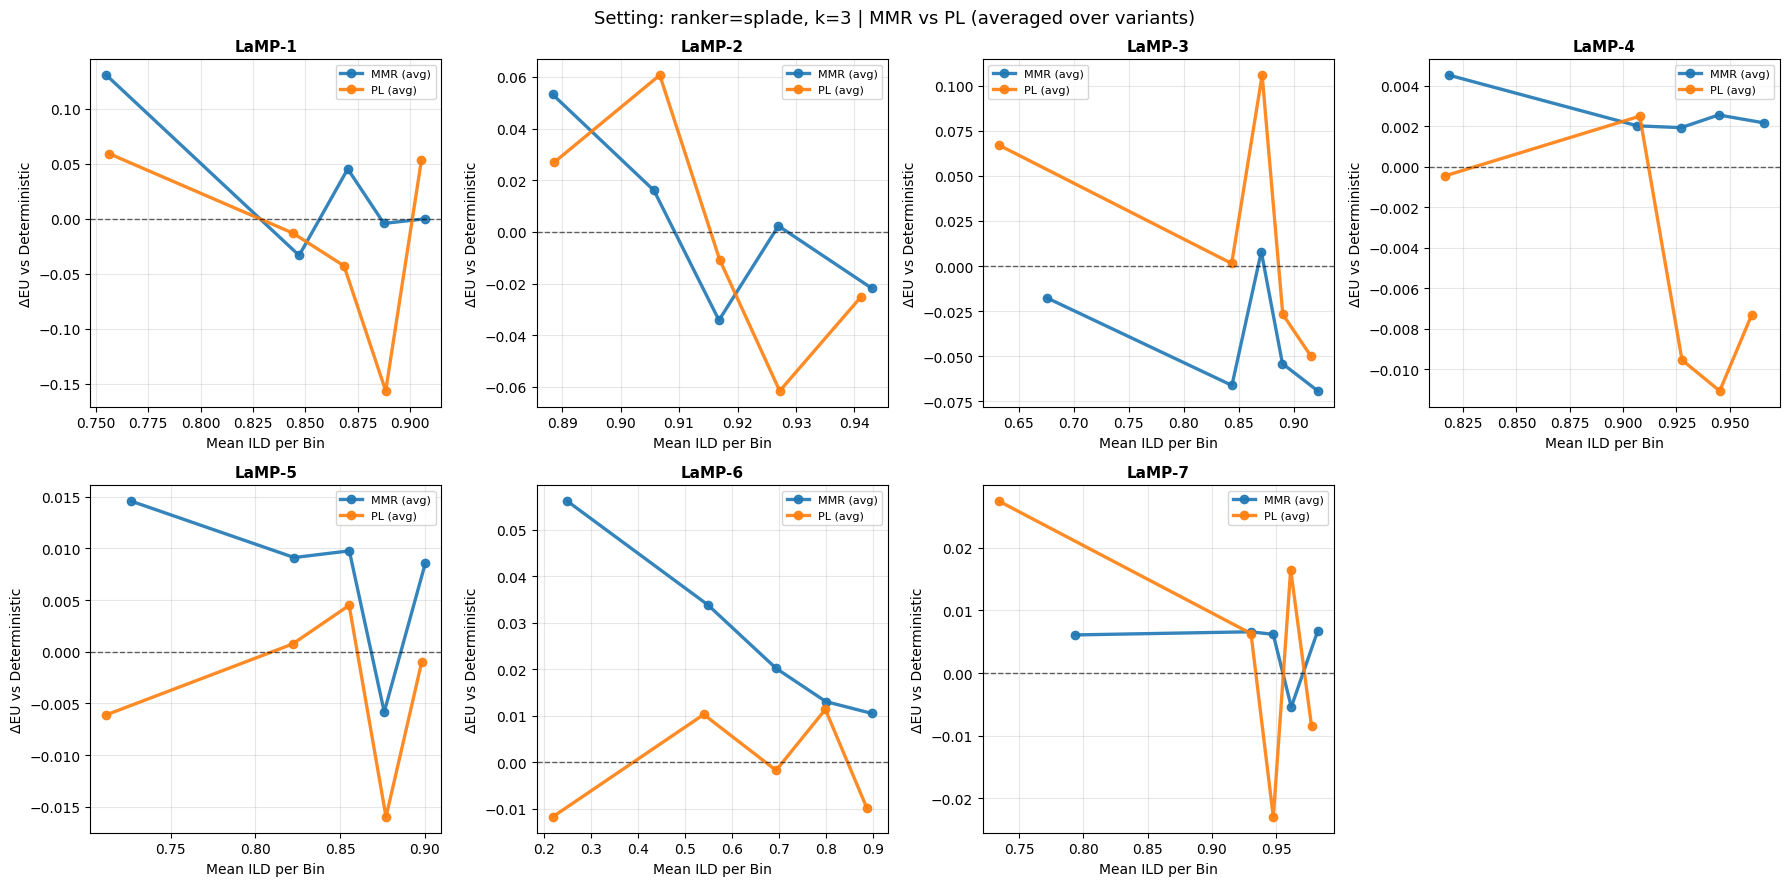

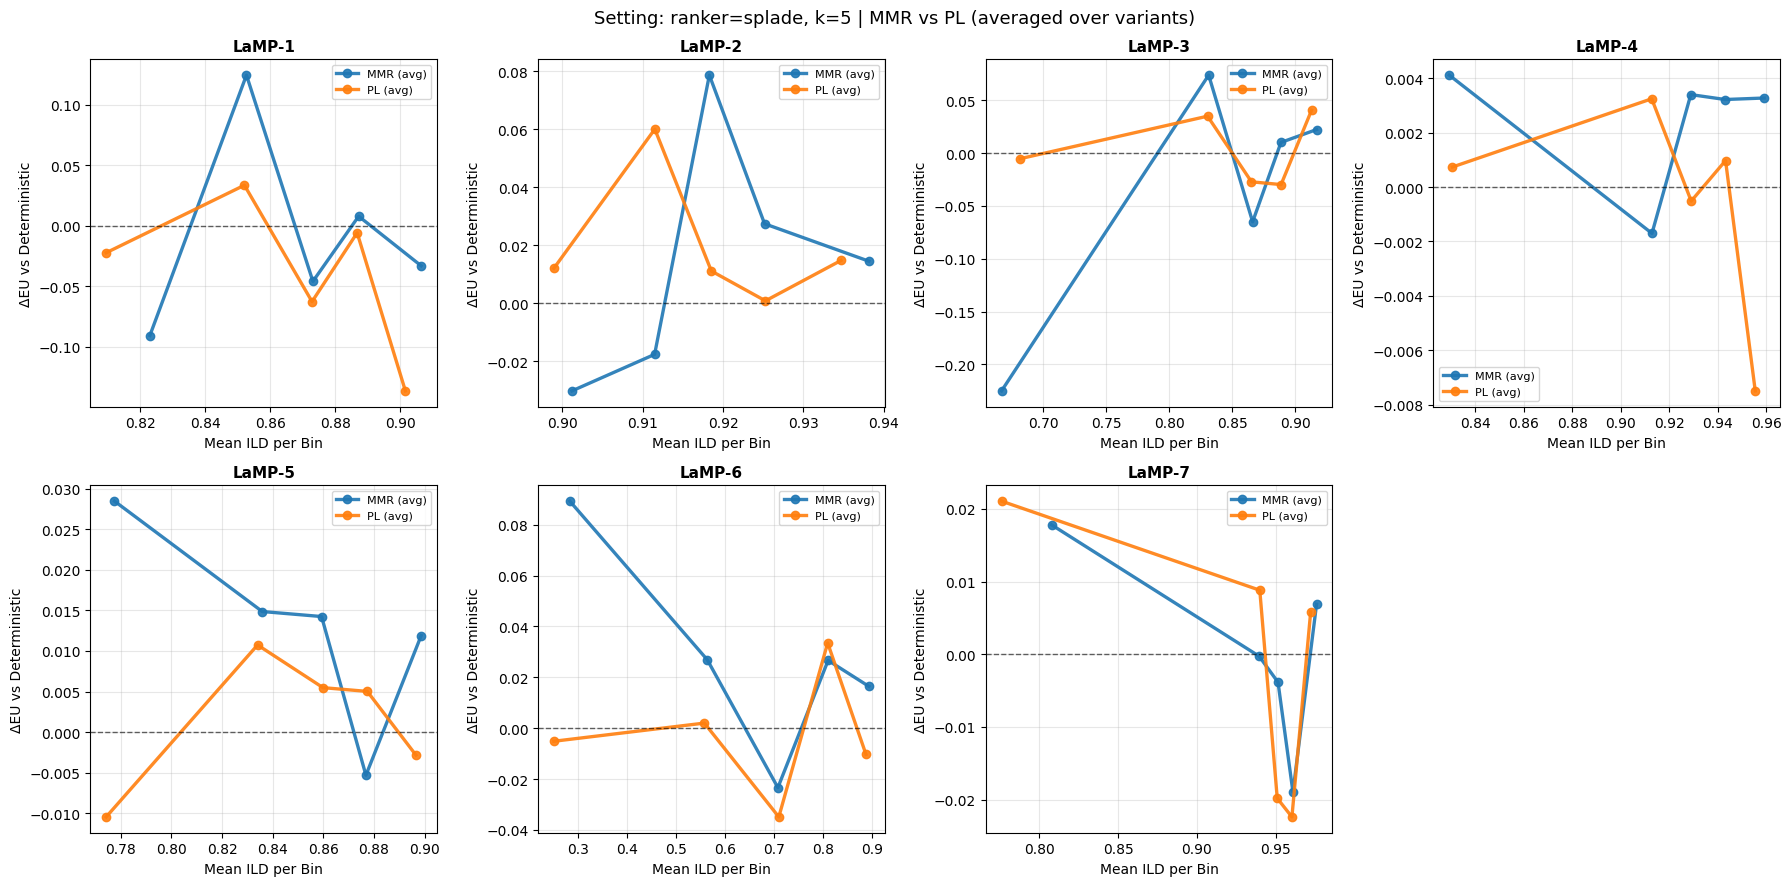

Per-setting graph rendering complete.


In [38]:
# Per-setting graph: one figure per (ranker, top_k)
# Each figure shows MMR(avg) and PL(avg) curves per LaMP task.
if ild_bin_clean.empty:
    print("No ILD-bin data available. Run the ILD binning cell first.")
else:
    plot_src = ild_bin_clean.copy()
    is_mmr = plot_src["method"].str.startswith("mmr_l")
    is_pl = plot_src["method"].str.startswith("pl_a")
    plot_src = plot_src[is_mmr | is_pl].copy()

    if plot_src.empty:
        print("No MMR/PL rows found to aggregate.")
    else:
        plot_src["method_family"] = np.where(plot_src["method"].str.startswith("mmr_"), "mmr", "pl")

        agg_data = (
            plot_src.groupby(["ranker", "top_k", "lamp_num", "method_family", "bin_label"], observed=True)
            .apply(
                lambda g: pd.Series(
                    {
                        "mean_ild": weighted_mean(g["mean_ild"], g["n_rows"]),
                        "delta_eu_vs_det": weighted_mean(g["delta_eu_vs_det"], g["n_rows"]),
                        "n_rows": int(g["n_rows"].sum()),
                    }
                )
            )
            .reset_index()
        )

        colors = {"mmr": "#1f77b4", "pl": "#ff7f0e"}
        labels = {"mmr": "MMR (avg)", "pl": "PL (avg)"}

        settings = agg_data[["ranker", "top_k"]].drop_duplicates().sort_values(["ranker", "top_k"])
        print(f"Rendering {len(settings)} setting-specific figures...")

        for _, setting in settings.iterrows():
            ranker = setting["ranker"]
            top_k = setting["top_k"]
            subset = agg_data[(agg_data["ranker"] == ranker) & (agg_data["top_k"] == top_k)].copy()
            if subset.empty:
                continue

            lamp_vals = sorted(subset["lamp_num"].unique())
            fig, axes = plt.subplots(2, 4, figsize=(18, 9))
            axes = axes.flatten()

            for idx, lamp_num in enumerate(lamp_vals):
                ax = axes[idx]
                lamp_agg = subset[subset["lamp_num"] == lamp_num]

                for method_family in ["mmr", "pl"]:
                    method_data = lamp_agg[lamp_agg["method_family"] == method_family].sort_values("mean_ild")
                    if method_data.empty:
                        continue
                    ax.plot(
                        method_data["mean_ild"],
                        method_data["delta_eu_vs_det"],
                        marker="o",
                        label=labels[method_family],
                        linewidth=2.4,
                        markersize=6,
                        alpha=0.9,
                        color=colors[method_family],
                    )

                ax.axhline(y=0, color="black", linestyle="--", linewidth=1, alpha=0.6)
                ax.set_xlabel("Mean ILD per Bin", fontsize=10)
                ax.set_ylabel("ΔEU vs Deterministic", fontsize=10)
                ax.set_title(f"LaMP-{int(lamp_num)}", fontsize=11, fontweight="bold")
                ax.grid(True, alpha=0.3)
                ax.legend(fontsize=8, loc="best")

            for j in range(len(lamp_vals), len(axes)):
                fig.delaxes(axes[j])

            fig.suptitle(f"Setting: ranker={ranker}, k={int(top_k)} | MMR vs PL (averaged over variants)", fontsize=13)
            plt.tight_layout()
            plt.show()

        print("Per-setting graph rendering complete.")

In [39]:
# Final summary (setting-aware)
print("=" * 100)
print("SETTING-AWARE SUMMARY: ILD-binned ΔEU vs deterministic")
print("=" * 100)

if ild_bin_clean.empty:
    print("No ILD-bin data available.")
else:
    by_setting_method = (
        ild_bin_clean.groupby(["ranker", "top_k", "method"], observed=True)
        .agg(avg_delta_eu=("delta_eu_vs_det", "mean"), total_rows=("n_rows", "sum"))
        .reset_index()
        .sort_values(["ranker", "top_k", "avg_delta_eu"], ascending=[True, True, False])
    )

    print("Top methods per setting (higher avg ΔEU is better):")
    display(by_setting_method.groupby(["ranker", "top_k"], observed=True).head(6))

    family_src = ild_bin_clean[ild_bin_clean["method"].str.startswith(("mmr_l", "pl_a"))].copy()
    family_src["family"] = np.where(family_src["method"].str.startswith("mmr_l"), "MMR", "PL")
    family_summary = (
        family_src.groupby(["ranker", "top_k", "family"], observed=True)["delta_eu_vs_det"]
        .mean()
        .unstack("family")
    )
    if not family_summary.empty:
        family_summary["PL_minus_MMR"] = family_summary.get("PL", np.nan) - family_summary.get("MMR", np.nan)
        print("\nFamily-level summary per setting:")
        display(family_summary)

print("\nFigures above are now split by setting (one figure per ranker/top_k pair).")
print("=" * 100)

SETTING-AWARE SUMMARY: ILD-binned ΔEU vs deterministic
Top methods per setting (higher avg ΔEU is better):


,ranker,top_k,method,avg_delta_eu,total_rows
0,bm25,5,mmr_l025,0.013591,3133
6,bm25,5,pl_a2,0.007956,3384
7,bm25,5,pl_a4,0.003386,3384
1,bm25,5,mmr_l045,0.001786,3317
5,bm25,5,pl_a1,-0.000082,3381
2,bm25,5,mmr_l055,-0.000131,3375
10,contriever,5,mmr_l045,0.015077,3325
9,contriever,5,mmr_l025,0.008200,3249
15,contriever,5,pl_a2,0.006771,3336
14,contriever,5,pl_a1,0.003676,3337



Family-level summary per setting:


family                 MMR        PL  PL_minus_MMR
ranker     top_k                                  
bm25       5      0.001626  0.002451      0.000825
contriever 5      0.004266  0.001757     -0.002509
gold       5      0.011480  0.001300     -0.010180
splade     3      0.015280  0.008133     -0.007147
           5      0.008566  0.000504     -0.008063


Figures above are now split by setting (one figure per ranker/top_k pair).
